# Week 3 — Nemotron Nano 4B Experiments
**Model:** `nemotron-3-nano:4b` via Ollama (Javi-ASUS — RTX 4060 8 GB)  
**Dataset:** `data/personas_sample_500.csv` (balanced, cleaned before inference)  
**Label definition:** college = associates + bachelors + graduate (per advisor feedback)  
**Experiments:** Zero-shot · Few-shot  

**Baselines to beat (Week 1 — updated definition):**
- Random Forest: 77.09% accuracy · Macro F1 0.7701 · AUC-ROC 0.8556
- XGBoost: 71.50% accuracy · Macro F1 0.7149 · AUC-ROC 0.7812

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import requests
import time
import re
import os

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

print("Imports OK")


Imports OK


## 2. Configuration

In [2]:
OLLAMA_URL  = "http://localhost:11434/v1/chat/completions"
MODEL_NAME  = "nemotron-3-nano:4b"
SAMPLE_PATH = "../data/personas_sample_500.csv"
RESULTS_DIR = "../results"

# Week 1 baselines — associates included as college
BASELINES = {
    "Random Forest": {"accuracy": 0.7709, "macro_f1": 0.7701, "auc_roc": 0.8556, "ms_per_row": 0.011},
    "XGBoost":       {"accuracy": 0.7150, "macro_f1": 0.7149, "auc_roc": 0.7812, "ms_per_row": 0.001},
}

# Verify Ollama is running
try:
    r = requests.get("http://localhost:11434/api/tags", timeout=5)
    models = [m["name"] for m in r.json().get("models", [])]
    print(f"Ollama running. Models: {models}")
    print(f"Target model present: {MODEL_NAME in models}")
except Exception as e:
    print(f"Ollama not reachable: {e}")


Ollama running. Models: ['hf.co/nvidia/NVIDIA-Nemotron-3-Nano-4B-GGUF:latest', 'nemotron-3-nano:4b', 'nemotron-mini:latest']
Target model present: True


## 3. Load, Filter, and Clean Sample

This section does three things before any inference runs:
1. Load the 500-row sample
2. Filter out uninformative occupation rows
3. Detect and fix label noise (professional jobs mislabeled as not_college)

> **Why clean before inference:** Running Nemotron on noisy labels means the model gets
> penalized for being correct. Fixing first gives honest results in one clean pass.

In [3]:
# ── Load and filter ──────────────────────────────────────────────────
sample = pd.read_csv(SAMPLE_PATH)

sample = sample[
    ~sample["occupation"].str.lower().str.strip().str.replace("_", " ").isin([
        "no occupation", "not in workforce", ""
    ]) &
    (sample["occupation"].str.strip() != "") &
    (sample["occupation"].notna())
].reset_index(drop=True)

print(f"After filter: {len(sample)} rows")
print(f"Remaining bad rows: {(sample['occupation'].str.lower().str.strip().str.replace('_', ' ') == 'no occupation').sum()}")
print()

# ── Identify label noise ──────────────────────────────────────────────
# These occupations require a college degree in the real world
# but were mislabeled as not_college in the synthetic dataset
COLLEGE_OCCUPATIONS = [
    # Healthcare
    "surgeon", "physician", "doctor", "nurse", "registered nurse",
    "occupational therapist", "physical therapist", "pharmacist",
    "dentist", "veterinarian", "optometrist", "radiologist",
    "anesthesiologist", "psychiatrist", "psychologist",
    # Engineering & Technology
    "software developer", "software engineer", "engineer",
    "mechanical engineer", "electrical engineer", "civil engineer",
    "chemical engineer", "database administrator", "computer systems analyst",
    "information security analyst", "mathematical science occupation",
    # Business & Finance
    "accountant", "auditor", "financial manager", "financial analyst",
    "budget analyst", "actuary", "economist", "statistician",
    "management analyst", "lawyer", "attorney", "judge",
    # Education
    "teacher", "elementary or middle school teacher",
    "secondary school teacher", "professor", "postsecondary teacher",
    "education or childcare administrator",
    # Architecture & Science
    "architect", "urban planner", "chemist", "physicist",
    "biological scientist", "environmental scientist",
    # Other professional
    "social worker", "librarian",
]

def is_noise(row):
    """True if row has a professional occupation but is labeled not_college."""
    if row["label_name"] != "not_college":
        return False
    occ = row["occupation"].lower().replace("_", " ").strip()
    return any(c in occ for c in COLLEGE_OCCUPATIONS)

# Find and fix noise rows
noise_mask = sample.apply(is_noise, axis=1)
noise_count = noise_mask.sum()

print(f"Label noise rows detected: {noise_count} ({noise_count/len(sample)*100:.1f}%)")
print("Examples:")
for _, row in sample[noise_mask].head(5).iterrows():
    print(f"  {row['occupation']} → labeled {row['label_name']} (should be college)")

# Fix the labels
sample.loc[noise_mask, "label_name"] = "college"
sample.loc[noise_mask, "label"] = 1

print(f"\nLabel distribution after cleaning:")
print(sample["label_name"].value_counts())

# Save clean sample for Week 4 reuse
os.makedirs("../data", exist_ok=True)
sample.to_csv("../data/personas_sample_500_clean.csv", index=False)
print(f"\nSaved clean sample: data/personas_sample_500_clean.csv")


After filter: 500 rows
Remaining bad rows: 0

Label noise rows detected: 31 (6.2%)
Examples:
  software_developer → labeled not_college (should be college)
  engineer → labeled not_college (should be college)
  social_worker → labeled not_college (should be college)
  architectural_or_engineering_manager → labeled not_college (should be college)
  lawyer → labeled not_college (should be college)

Label distribution after cleaning:
label_name
college        255
not_college    245
Name: count, dtype: int64

Saved clean sample: data/personas_sample_500_clean.csv


## 4. Helper Functions

In [4]:
SYSTEM_PROMPT = """You are an education level classifier. Given a person's demographic information,
predict whether they are college-educated (have a bachelor's degree or higher) or not.
Think step by step, then respond with ONLY one of these two labels on the final line: college or not_college."""


def serialize_row(row):
    return (
        f"A {int(row['age'])}-year-old {str(row['sex']).lower().strip()}, "
        f"{str(row['marital_status']).replace('_', ' ').strip()}, "
        f"working as a {str(row['occupation']).replace('_', ' ').strip()}. "
        f"Located in {str(row['state']).strip()}."
    )


def build_zero_shot_prompt(row):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": (
            f"Classify this person's education level:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]


def build_few_shot_prompt(row, examples):
    example_text = ""
    for ex in examples:
        example_text += f"Person: {serialize_row(ex)}\nLabel: {ex['label_name']}\n\n"
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": (
            f"Here are some labeled examples:\n\n{example_text}"
            f"Now classify this person:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]


def parse_response(content):
    think_match = re.search(r"<think>(.*?)</think>", content, re.DOTALL)
    trace = think_match.group(1).strip() if think_match else ""
    label_match = re.search(r"\b(not_college|college)\b", content, re.IGNORECASE)
    label = label_match.group(1).lower() if label_match else "UNKNOWN"
    return label, trace


def classify_row(messages, timeout=120):
    payload = {
        "model": MODEL_NAME,
        "messages": messages,
        "max_tokens": 1024,
        "temperature": 0.1,
        "stream": False,
        "options": {"num_ctx": 4096},
    }
    start = time.time()
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=timeout).json()
        elapsed = time.time() - start
        content = response["choices"][0]["message"]["content"]
        tokens  = response.get("usage", {}).get("completion_tokens", 0)
        label, trace = parse_response(content)
    except Exception as e:
        elapsed = time.time() - start
        label, trace, tokens, content = "ERROR", str(e), 0, str(e)
    return {"label": label, "trace": trace, "raw": content,
            "time_ms": round(elapsed * 1000), "tokens": tokens}


print("All helper functions defined.")


All helper functions defined.


## 5. Evaluation Helper

In [5]:
def evaluate_llm_results(results_df, run_name):
    label_map = {"college": 1, "not_college": 0}
    valid = results_df[results_df["pred_label"].isin(["college", "not_college"])].copy()
    unknown_count = len(results_df) - len(valid)
    y_true = valid["true_label"].map(label_map)
    y_pred = valid["pred_label"].map(label_map)
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average="macro")
    auc  = roc_auc_score(y_true, y_pred)
    avg_ms     = results_df["time_ms"].mean()
    avg_tokens = results_df["tokens"].mean()
    print(f"\n{'='*50}")
    print(f"  {run_name}")
    print(f"{'='*50}")
    print(f"  Rows evaluated:  {len(valid)} / {len(results_df)}")
    print(f"  Unknown:         {unknown_count}")
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  Macro F1:        {f1:.4f}")
    print(f"  AUC-ROC:         {auc:.4f}")
    print(f"  Avg time/row:    {avg_ms:.0f}ms")
    print(f"  Avg tokens:      {avg_tokens:.0f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["not_college", "college"]))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=["not_college", "college"]).plot(ax=ax, colorbar=False)
    ax.set_title(run_name)
    plt.tight_layout()
    fname = f"{RESULTS_DIR}/cm_{run_name.replace(' ', '_').lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    return {
        "model": run_name, "accuracy": round(acc, 4), "macro_f1": round(f1, 4),
        "auc_roc": round(auc, 4), "ms_per_row": round(avg_ms, 1),
        "avg_tokens": round(avg_tokens, 1), "unknown": unknown_count,
        "n_samples": len(valid), "week": 3, "device": "local-rtx4060",
        "dataset": "nvidia/Nemotron-Personas-USA",
    }

all_results = []
print("evaluate_llm_results() defined.")


evaluate_llm_results() defined.


## 6. Few-shot Example Pool

Sampled from the **cleaned** sample so all 5 examples have correct labels.

In [6]:
# Sample from cleaned sample — fixed random_state for reproducibility
# 3 college + 2 not_college
fs_college = sample[sample["label_name"] == "college"].sample(3, random_state=1)
fs_not     = sample[sample["label_name"] == "not_college"].sample(2, random_state=1)
few_shot_examples = pd.concat([fs_college, fs_not]).sample(frac=1, random_state=1).to_dict("records")

print("Few-shot examples (sampled from cleaned sample):")
for ex in few_shot_examples:
    print(f"  {serialize_row(ex)} → {ex['label_name']}")


Few-shot examples (sampled from cleaned sample):
  A 51-year-old male, married present, working as a elementary or middle school teacher. Located in CA. → college
  A 21-year-old male, never married, working as a social worker. Located in NY. → college
  A 26-year-old male, never married, working as a graphic designer. Located in PR. → not_college
  A 33-year-old female, never married, working as a retail salesperson. Located in NY. → college
  A 41-year-old female, never married, working as a electrical or electronics repairer industrial or utility. Located in GA. → not_college


## 7. Experiment A — Zero-shot (500 rows)

No examples given. Nemotron classifies from the description alone.

> **Expected time:** ~30 minutes. Run and come back.

In [7]:
print(f"Starting zero-shot on {len(sample)} rows (cleaned labels)...")
print(f"Estimated time: ~{len(sample) * 4 / 60:.0f} minutes\n")

zs_results = []
t_start = time.time()

for i, row in sample.iterrows():
    messages = build_zero_shot_prompt(row.to_dict())
    result   = classify_row(messages)
    zs_results.append({
        "row_id":     i,
        "input":      serialize_row(row.to_dict()),
        "true_label": row["label_name"],
        "pred_label": result["label"],
        "correct":    result["label"] == row["label_name"],
        "time_ms":    result["time_ms"],
        "tokens":     result["tokens"],
        "trace":      result["trace"],
        "raw":        result["raw"],
    })
    if (i + 1) % 50 == 0:
        elapsed   = time.time() - t_start
        done      = i + 1
        remaining = (elapsed / done) * (len(sample) - done)
        print(f"  Row {done:3d}/{len(sample)} | Elapsed: {elapsed/60:.1f}min | Remaining: ~{remaining/60:.1f}min")

zs_df = pd.DataFrame(zs_results)
os.makedirs(RESULTS_DIR, exist_ok=True)
zs_df.to_csv(f"{RESULTS_DIR}/week3_zeroshot_raw.csv", index=False)
print(f"\nDone! Total time: {(time.time()-t_start)/60:.1f} minutes")
print(f"Saved: results/week3_zeroshot_raw.csv")


Starting zero-shot on 500 rows (cleaned labels)...
Estimated time: ~33 minutes

  Row  50/500 | Elapsed: 3.2min | Remaining: ~28.5min
  Row 100/500 | Elapsed: 6.1min | Remaining: ~24.4min
  Row 150/500 | Elapsed: 9.0min | Remaining: ~21.0min
  Row 200/500 | Elapsed: 11.9min | Remaining: ~17.8min
  Row 250/500 | Elapsed: 14.9min | Remaining: ~14.9min
  Row 300/500 | Elapsed: 17.9min | Remaining: ~11.9min
  Row 350/500 | Elapsed: 20.9min | Remaining: ~9.0min
  Row 400/500 | Elapsed: 23.8min | Remaining: ~5.9min
  Row 450/500 | Elapsed: 26.8min | Remaining: ~3.0min
  Row 500/500 | Elapsed: 29.8min | Remaining: ~0.0min

Done! Total time: 29.8 minutes
Saved: results/week3_zeroshot_raw.csv


## 8. Zero-shot Results


  Nano 4B zero-shot
  Rows evaluated:  500 / 500
  Unknown:         0
  Accuracy:        0.6220
  Macro F1:        0.6118
  AUC-ROC:         0.6255
  Avg time/row:    3575ms
  Avg tokens:      92

              precision    recall  f1-score   support

 not_college       0.58      0.80      0.67       245
     college       0.70      0.45      0.55       255

    accuracy                           0.62       500
   macro avg       0.64      0.63      0.61       500
weighted avg       0.64      0.62      0.61       500



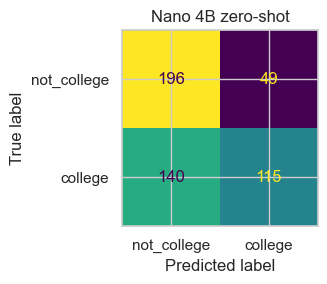

In [8]:
zs_metrics = evaluate_llm_results(zs_df, "Nano 4B zero-shot")
all_results.append(zs_metrics)


## 9. Experiment B — Few-shot (500 rows)

5 labeled examples shown before each classification.

> **Expected time:** ~60 minutes.

In [9]:
print(f"Starting few-shot on {len(sample)} rows (cleaned labels)...")
print(f"Estimated time: ~{len(sample) * 4.5 / 60:.0f} minutes\n")

fs_results = []
t_start = time.time()

for i, row in sample.iterrows():
    messages = build_few_shot_prompt(row.to_dict(), few_shot_examples)
    result   = classify_row(messages)
    fs_results.append({
        "row_id":     i,
        "input":      serialize_row(row.to_dict()),
        "true_label": row["label_name"],
        "pred_label": result["label"],
        "correct":    result["label"] == row["label_name"],
        "time_ms":    result["time_ms"],
        "tokens":     result["tokens"],
        "trace":      result["trace"],
        "raw":        result["raw"],
    })
    if (i + 1) % 50 == 0:
        elapsed   = time.time() - t_start
        done      = i + 1
        remaining = (elapsed / done) * (len(sample) - done)
        print(f"  Row {done:3d}/{len(sample)} | Elapsed: {elapsed/60:.1f}min | Remaining: ~{remaining/60:.1f}min")

fs_df = pd.DataFrame(fs_results)
fs_df.to_csv(f"{RESULTS_DIR}/week3_fewshot_raw.csv", index=False)
print(f"\nDone! Total time: {(time.time()-t_start)/60:.1f} minutes")
print(f"Saved: results/week3_fewshot_raw.csv")


Starting few-shot on 500 rows (cleaned labels)...
Estimated time: ~38 minutes

  Row  50/500 | Elapsed: 5.6min | Remaining: ~50.2min
  Row 100/500 | Elapsed: 11.2min | Remaining: ~44.8min
  Row 150/500 | Elapsed: 16.5min | Remaining: ~38.4min
  Row 200/500 | Elapsed: 22.3min | Remaining: ~33.4min
  Row 250/500 | Elapsed: 27.7min | Remaining: ~27.7min
  Row 300/500 | Elapsed: 33.2min | Remaining: ~22.1min
  Row 350/500 | Elapsed: 39.1min | Remaining: ~16.8min
  Row 400/500 | Elapsed: 44.7min | Remaining: ~11.2min
  Row 450/500 | Elapsed: 50.5min | Remaining: ~5.6min
  Row 500/500 | Elapsed: 56.2min | Remaining: ~0.0min

Done! Total time: 56.2 minutes
Saved: results/week3_fewshot_raw.csv


## 10. Few-shot Results


  Nano 4B few-shot
  Rows evaluated:  497 / 500
  Unknown:         3
  Accuracy:        0.7264
  Macro F1:        0.7263
  AUC-ROC:         0.7265
  Avg time/row:    6744ms
  Avg tokens:      306

              precision    recall  f1-score   support

 not_college       0.71      0.73      0.72       243
     college       0.74      0.72      0.73       254

    accuracy                           0.73       497
   macro avg       0.73      0.73      0.73       497
weighted avg       0.73      0.73      0.73       497



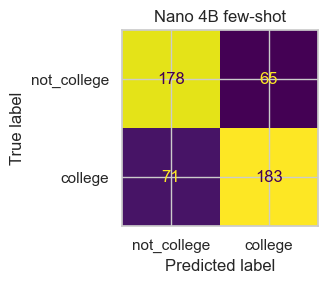

In [10]:
fs_metrics = evaluate_llm_results(fs_df, "Nano 4B few-shot")
all_results.append(fs_metrics)


In [22]:
unknowns = fs_df[~fs_df["pred_label"].isin(["college", "not_college"])]
print(unknowns[["input", "raw"]].to_string())

                                                                                              input raw
161           A 56-year-old female, married present, working as a nursing assistant. Located in CA.    
304  A 29-year-old female, never married, working as a information security analyst. Located in CA.    
446        A 37-year-old female, married present, working as a construction manager. Located in TX.    


In [23]:
for _, row in unknowns.iterrows():
    print(f"Input: {row['input']}")
    print(f"Raw:   {row['raw'][:300]}")
    print()

Input: A 56-year-old female, married present, working as a nursing assistant. Located in CA.
Raw:   

Input: A 29-year-old female, never married, working as a information security analyst. Located in CA.
Raw:   

Input: A 37-year-old female, married present, working as a construction manager. Located in TX.
Raw:   



## 11. Full Comparison — Nano 4B vs Week 1 Baselines

In [11]:
baseline_rows = [
    {"model": "Random Forest", "accuracy": 0.7709, "macro_f1": 0.7701,
     "auc_roc": 0.8556, "ms_per_row": 0.011, "week": 1, "device": "local-cpu"},
    {"model": "XGBoost", "accuracy": 0.7150, "macro_f1": 0.7149,
     "auc_roc": 0.7812, "ms_per_row": 0.001, "week": 1, "device": "local-cpu"},
]

comparison_df = pd.DataFrame(baseline_rows + all_results)
print("=== COMPARISON: Week 1 Baselines vs Nano 4B (cleaned labels) ===")
print(comparison_df[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row"]].to_string(index=False))


=== COMPARISON: Week 1 Baselines vs Nano 4B (cleaned labels) ===
            model  accuracy  macro_f1  auc_roc  ms_per_row
    Random Forest    0.7709    0.7701   0.8556       0.011
          XGBoost    0.7150    0.7149   0.7812       0.001
Nano 4B zero-shot    0.6220    0.6118   0.6255    3575.500
 Nano 4B few-shot    0.7264    0.7263   0.7265    6743.800


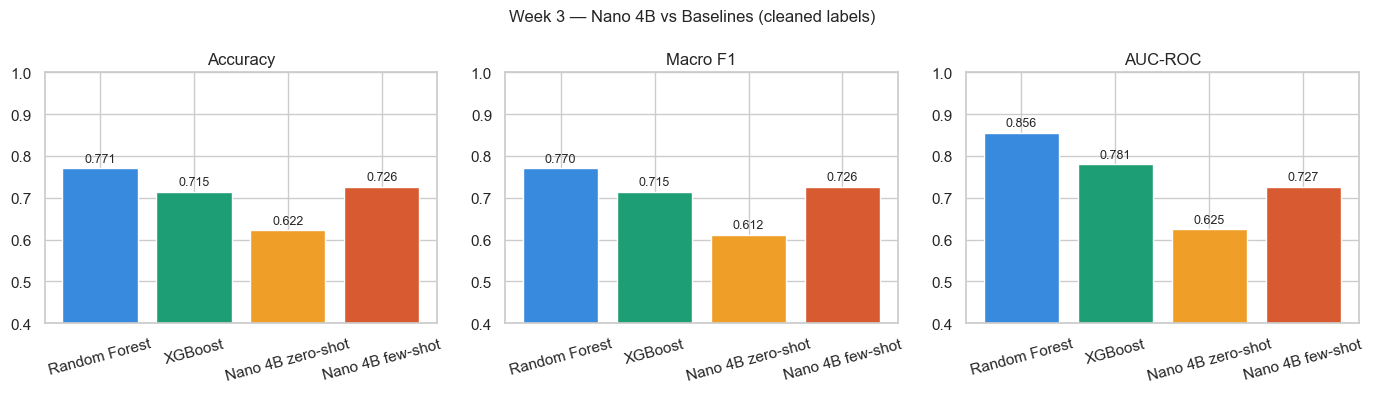

Saved: results/week3_comparison.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["accuracy", "macro_f1", "auc_roc"]
titles  = ["Accuracy", "Macro F1", "AUC-ROC"]
colors  = ["#378ADD", "#1D9E75", "#EF9F27", "#D85A30"]
for ax, metric, title in zip(axes, metrics, titles):
    vals  = comparison_df[metric].values
    names = comparison_df["model"].values
    bars  = ax.bar(names, vals, color=colors[:len(vals)])
    ax.set_title(title)
    ax.set_ylim(0.4, 1.0)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Week 3 — Nano 4B vs Baselines (cleaned labels)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week3_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week3_comparison.png")


## 12. Reasoning Traces

In [13]:
traces_df = zs_df[zs_df["trace"].str.len() > 10].copy()
print(f"Rows with reasoning traces: {len(traces_df)} / {len(zs_df)}")

if len(traces_df) > 0:
    print("\n=== CORRECT predictions with reasoning ===")
    for _, row in traces_df[traces_df["correct"] == True].head(3).iterrows():
        print(f"Input:     {row['input']}")
        print(f"Label:     {row['true_label']}")
        print(f"Reasoning: {row['trace'][:200]}")
        print()
    print("\n=== WRONG predictions with reasoning ===")
    for _, row in traces_df[traces_df["correct"] == False].head(3).iterrows():
        print(f"Input:     {row['input']}")
        print(f"True: {row['true_label']} | Predicted: {row['pred_label']}")
        print(f"Reasoning: {row['trace'][:200]}")
        print()
else:
    print("No reasoning traces — expected for 4B via Ollama API.")
    print("Full traces will be available from Nano 30B on FDS in Week 4.")


Rows with reasoning traces: 0 / 500
No reasoning traces — expected for 4B via Ollama API.
Full traces will be available from Nano 30B on FDS in Week 4.


## 13. K-Means Cluster Analysis

Clustering is done on the **cleaned sample** so accuracy per cluster
reflects true model performance without label noise distortion.

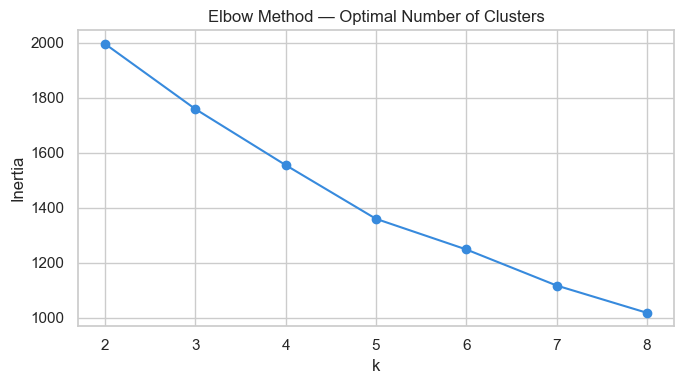

In [14]:
# ── Encode features for clustering ───────────────────────────────────
cluster_features = ['age', 'sex', 'marital_status', 'occupation', 'state']
X_cluster = sample[cluster_features].copy()

le_dict = {}
for col in ['sex', 'marital_status', 'occupation', 'state']:
    le = LabelEncoder()
    X_cluster[col] = le.fit_transform(X_cluster[col].astype(str))
    le_dict[col] = le

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ── Elbow plot ────────────────────────────────────────────────────────
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2, 9), inertias, marker='o', color='#378ADD')
ax.set_title('Elbow Method — Optimal Number of Clusters')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/kmeans_elbow.png', dpi=150)
plt.show()


In [15]:
# ── Run K-Means with k=4 ─────────────────────────────────────────────
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels_arr = km.fit_predict(X_scaled)

zs_clustered = zs_df.copy()
fs_clustered = fs_df.copy()
zs_clustered['cluster'] = cluster_labels_arr
fs_clustered['cluster'] = cluster_labels_arr

cluster_stats = []

for c in range(K):
    zs_rows = zs_clustered[zs_clustered['cluster'] == c]
    fs_rows = fs_clustered[fs_clustered['cluster'] == c]
    zs_acc  = zs_rows['correct'].mean()
    fs_acc  = fs_rows['correct'].mean()
    size    = len(zs_rows)
    college_rate = (zs_rows['true_label'] == 'college').mean()
    cluster_ids  = zs_rows['row_id'].values
    top_occ = sample.loc[sample.index.isin(cluster_ids), 'occupation'].value_counts().head(3).index.tolist()
    avg_age = sample.loc[sample.index.isin(cluster_ids), 'age'].mean()
    cluster_stats.append({
        'cluster': c, 'size': size,
        'zs_accuracy': round(zs_acc, 3), 'fs_accuracy': round(fs_acc, 3),
        'college_rate': round(college_rate, 3), 'avg_age': round(avg_age, 1),
        'top_occupations': ', '.join(top_occ),
    })
    print(f'\n── Cluster {c} ───────────────────────────────────────')
    print(f'  Size:               {size} rows')
    print(f'  Zero-shot accuracy: {zs_acc:.1%}')
    print(f'  Few-shot accuracy:  {fs_acc:.1%}')
    print(f'  College rate:       {college_rate:.1%}')
    print(f'  Avg age:            {avg_age:.1f}')
    print(f'  Top occupations:    {", ".join(top_occ)}')

cluster_df = pd.DataFrame(cluster_stats)
cluster_df.to_csv(f'{RESULTS_DIR}/week3_cluster_analysis.csv', index=False)
print('\nSaved: results/week3_cluster_analysis.csv')



── Cluster 0 ───────────────────────────────────────
  Size:               111 rows
  Zero-shot accuracy: 62.2%
  Few-shot accuracy:  77.5%
  College rate:       45.9%
  Avg age:            43.9
  Top occupations:    janitor_or_building_cleaner, driver_sales_worker_or_truck_driver, sales_representative_wholesale_or_manufacturing

── Cluster 1 ───────────────────────────────────────
  Size:               126 rows
  Zero-shot accuracy: 69.8%
  Few-shot accuracy:  77.8%
  College rate:       46.0%
  Avg age:            40.2
  Top occupations:    manager, software_developer, police_officer

── Cluster 2 ───────────────────────────────────────
  Size:               158 rows
  Zero-shot accuracy: 60.1%
  Few-shot accuracy:  66.5%
  College rate:       56.3%
  Avg age:            48.0
  Top occupations:    elementary_or_middle_school_teacher, customer_service_representative, accountant_or_auditor

── Cluster 3 ───────────────────────────────────────
  Size:               105 rows
  Zero-shot

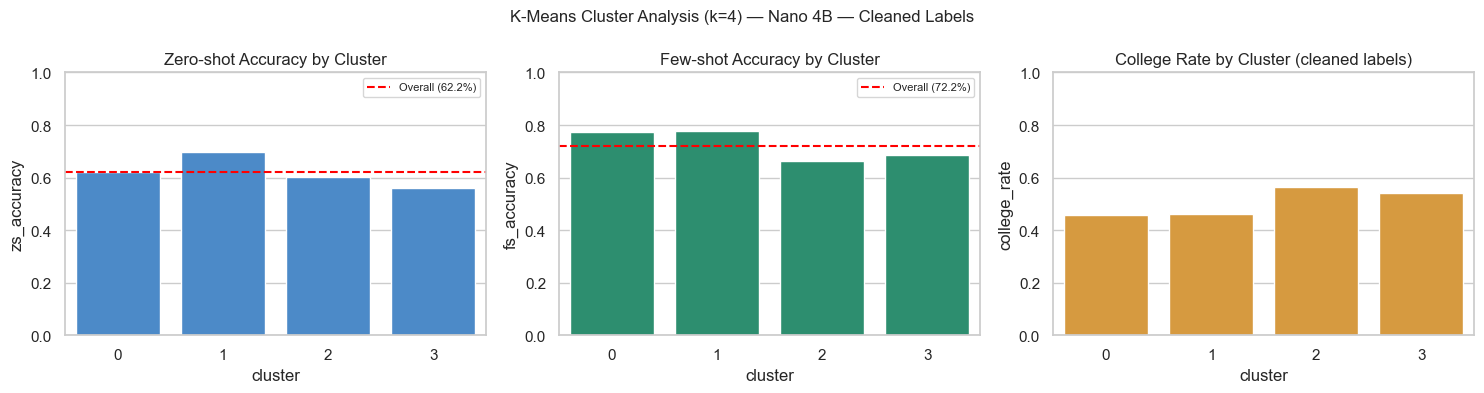

Saved: results/week3_cluster_accuracy.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=cluster_df, x='cluster', y='zs_accuracy', color='#378ADD', ax=axes[0])
axes[0].axhline(y=zs_df['correct'].mean(), color='red', linestyle='--',
                label=f'Overall ({zs_df["correct"].mean():.1%})')
axes[0].set_title('Zero-shot Accuracy by Cluster')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

sns.barplot(data=cluster_df, x='cluster', y='fs_accuracy', color='#1D9E75', ax=axes[1])
axes[1].axhline(y=fs_df['correct'].mean(), color='red', linestyle='--',
                label=f'Overall ({fs_df["correct"].mean():.1%})')
axes[1].set_title('Few-shot Accuracy by Cluster')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

sns.barplot(data=cluster_df, x='cluster', y='college_rate', color='#EF9F27', ax=axes[2])
axes[2].set_title('College Rate by Cluster (cleaned labels)')
axes[2].set_ylim(0, 1)

plt.suptitle(f'K-Means Cluster Analysis (k={K}) — Nano 4B — Cleaned Labels', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/week3_cluster_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/week3_cluster_accuracy.png')


## 14. Save Results to metrics.csv

In [17]:
metrics_path = f"{RESULTS_DIR}/metrics.csv"
try:
    existing = pd.read_csv(metrics_path)
    existing = existing[existing["week"] != 3]
    updated  = pd.concat([existing, pd.DataFrame(all_results)], ignore_index=True)
except FileNotFoundError:
    updated = pd.DataFrame(all_results)

updated.to_csv(metrics_path, index=False)
print(f"Saved: {metrics_path}")
print()
print(updated[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row", "week"]].to_string(index=False))


Saved: ../results/metrics.csv

                    model  accuracy  macro_f1  auc_roc  ms_per_row  week
Random Forest (100 trees)    0.7709    0.7701   0.8556       0.007     1
                  XGBoost    0.7150    0.7149   0.7812       0.001     1
        Nano 4B zero-shot    0.6220    0.6118   0.6255    3575.500     3
         Nano 4B few-shot    0.7264    0.7263   0.7265    6743.800     3


## 15. Week 3 Summary

Fill in after running all cells:

| Model | Accuracy | Macro F1 | AUC-ROC | Time/row |
|---|---|---|---|---|
| Random Forest (Week 1) | 77.09% | 0.7701 | 0.8556 | 0.011 ms |
| XGBoost (Week 1) | 71.50% | 0.7149 | 0.7812 | 0.001 ms |
| Nano 4B zero-shot | ___ | ___ | ___ | ___ ms |
| Nano 4B few-shot | ___ | ___ | ___ | ___ ms |

**Label definition:** college = associates + bachelors + graduate  
**Label noise fixed:** professional occupations mislabeled as not_college corrected before inference  
**Clean sample saved:** `data/personas_sample_500_clean.csv` — reuse in Week 4

**Observations:**
- Did few-shot improve over zero-shot?
- Which cluster had the highest accuracy?
- Which cluster gained most from few-shot?


**Next week:** Same experiments on FDS with Nano 30B + reasoning ON vs OFF.